# Alunos
Fernando Bianchi - 00335450

Mateus Pletsch - 00338372

# Setup

In [1]:
!git clone https://github.com/Febianchi/fernando-matheus

Cloning into 'fernando-matheus'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 31 (delta 6), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 10.10 MiB | 21.64 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd fernando-matheus/

/content/fernando-matheus


In [3]:
!pip install pylhe
#!pip install git+https://github.com/scikit-hep/pylhe.git --quiet
!pip install matplotlib numpy --quiet
!pip install pylhe awkward vector
!gzip -d -k -f {'data/sinal.lhe.gz'} # unpack files
!gzip -d -k -f {'data/fundo.lhe.gz'}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 909.5/909.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.3/181.3 kB 2.8 MB/s eta 0:00:00


In [4]:
import pylhe
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
from pathlib import Path
from pprint import pprint
import gzip
import math

# Tabela do PDG

| ID | Partícula | Símbolo | Tipo |
| :---: | :--- | :---: | :--- |
| **1** | Down Quark | $d$ | Quark |
| **2** | Up Quark | $u$ | Quark |
| **3** | Strange Quark | $s$ | Quark |
| **4** | Charm Quark | $c$ | Quark |
| **5** | Bottom Quark | $b$ | Quark |
| **6** | Top Quark | $t$ | Quark |
| | | | |
| **11** | Elétron | $e^-$ | Lépton |
| **12** | Neutrino do Elétron | $\nu_e$ | Lépton |
| **13** | Múon | $\mu^⁻$ | Lépton |
| **14** | Neutrino do Múon | $\nu_\mu$ | Lépton |
| **15** | Tau | $\tau^-$ | Lépton |
| **16** | Neutrino do Tau | $\nu_\tau$ | Lépton |
| | | | |
| **21** | Glúon | $g$ | Bóson |
| **22** | Fóton | $\gamma$ | Bóson |
| **23** | Z Boson | $Z^0$ | Bóson |
| **24** | W Boson | $W^+$ | Bóson |
| **25** | Higgs Boson | $H$ | Bóson |

---
**Regra dos Sinais:**
* **Positivo (+):** Partícula (ex: `6` é o Top).
* **Negativo (-):** Antipartícula (ex: `-6` é o Anti-Top, `-24` é o $W^-$).
* **Exceção:** Glúons e Bosons Z/H/Fóton são suas próprias antipartículas (ou não têm distinção de carga no ID básico), então geralmente aparecem positivos.

# [1] Leitura do Arquivo LHE utilizando pylhe

In [5]:
# reading .lhe file to understand the format

with gzip.open('data/sinal.lhe.gz', 'rt') as f:
    content = f.read()
print(content[:30000])

<LesHouchesEvents version="3.0">
<header>
<!--
#*********************************************************************
#                                                                    *
#                        MadGraph5_aMC@NLO                           *
#                                                                    *
#                           Going Beyond                             *
#                                                                    *
#                   http://madgraph.hep.uiuc.edu                     *
#                   http://madgraph.phys.ucl.ac.be                   *
#                   http://amcatnlo.cern.ch                          *
#                                                                    *
#                     The MadGraph5_aMC@NLO team                     *
#                                                                    *
#....................................................................*
#                             

In [6]:
fundo_path = "data/fundo.lhe"
sinal_path = "data/sinal.lhe"
fundo_file = pylhe.read_lhe(fundo_path)
sinal_file = pylhe.read_lhe(sinal_path)

# [2a] Investigação Preliminar do Arquivo


In [7]:
# Carregar em lista (permisso para arquivos moderados)
print("Convertendo generator em lista")
fundo_events = list(pylhe.read_lhe(fundo_path))
sinal_events = list(pylhe.read_lhe(sinal_path))

print(f"Número total de eventos no fundo:  {len(fundo_events)}")
print(f"Número total de eventos no sinal:  {len(fundo_events)}")

Convertendo generator em lista


/tmp/ipython-input-10486056.py:3: DeprecationWarning: read_lhe is deprecated and will be removed in a future version. Use `LHEFile.fromfile(...).events` instead
  fundo_events = list(pylhe.read_lhe(fundo_path))
/tmp/ipython-input-10486056.py:4: DeprecationWarning: read_lhe is deprecated and will be removed in a future version. Use `LHEFile.fromfile(...).events` instead
  sinal_events = list(pylhe.read_lhe(sinal_path))


Número total de eventos no fundo:  10000
Número total de eventos no sinal:  10000


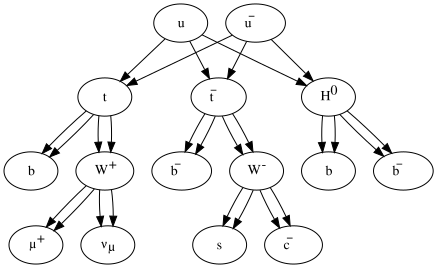

In [8]:
sinal_events[0] # curioso...

In [9]:
sinal_events[0].particles # printando particulas do primeiro evento

[LHEParticle(id=2, status=-1, mother1=0, mother2=0, color1=502, color2=0, px=0.0, py=0.0, pz=1358.3263507, e=1358.3263507, m=0.0, lifetime=0.0, spin=-1.0),
 LHEParticle(id=-2, status=-1, mother1=0, mother2=0, color1=0, color2=501, px=-0.0, py=-0.0, pz=-226.24941982, e=226.24941982, m=0.0, lifetime=0.0, spin=1.0),
 LHEParticle(id=6, status=2, mother1=1, mother2=2, color1=502, color2=0, px=224.12990053, py=-47.2396414, pz=483.21823437, e=562.04506764, m=173.0, lifetime=0.0, spin=0.0),
 LHEParticle(id=-6, status=2, mother1=1, mother2=2, color1=0, color2=501, px=-410.58184718, py=83.212214424, pz=155.26886083, e=479.10243686, m=173.0, lifetime=0.0, spin=0.0),
 LHEParticle(id=25, status=2, mother1=1, mother2=2, color1=0, color2=0, px=186.45194665, py=-35.972573024, pz=493.58983563, e=543.42826597, m=125.0, lifetime=0.0, spin=0.0),
 LHEParticle(id=5, status=1, mother1=3, mother2=3, color1=502, color2=0, px=196.20100827, py=-25.888762582, pz=320.03724877, e=376.31236264, m=4.7, lifetime=0.0, 

In [10]:
for event in itertools.islice(fundo_events, 0, 5):
    print(f"Event weight: {event.weights}")
    for particle in event.particles:
        print(f"  Particle PDG ID: {particle.id}, Px: {particle.px}, Py: {particle.py}, Pz: {particle.pz}, Energy: {particle.e}")

Event weight: {}
  Particle PDG ID: 21, Px: 0.0, Py: 0.0, Pz: 166.45154857, Energy: 166.45154857
  Particle PDG ID: 21, Px: -0.0, Py: -0.0, Pz: -905.61588125, Energy: 905.61588125
  Particle PDG ID: 6, Px: 31.66087569, Py: -108.68252378, Pz: -277.92695927, Energy: 346.39095934
  Particle PDG ID: -6, Px: 19.423711301, Py: -178.20718461, Pz: -259.41661356, Energy: 359.66798662
  Particle PDG ID: 23, Px: -51.084586991, Py: 286.88970839, Pz: -201.82075984, Energy: 366.00848385
  Particle PDG ID: -5, Px: 72.537520508, Py: -63.159792205, Pz: -77.039652214, Energy: 123.32091974
  Particle PDG ID: -24, Px: -53.113809207, Py: -115.0473924, Pz: -182.37696134, Energy: 236.34706687
  Particle PDG ID: 3, Px: 8.9262320006, Py: -76.479044454, Pz: -86.386854253, Energy: 115.72126186
  Particle PDG ID: -4, Px: -62.040041207, Py: -38.568347948, Pz: -95.990107088, Energy: 120.62580501
  Particle PDG ID: 5, Px: 53.168459605, Py: -110.82151854, Pz: -165.28287863, Energy: 206.03109969
  Particle PDG ID: 24,

# [2b] Investigação Preliminar dos Eventos

In [11]:
pdg_map = {
    1: 'd', 2: 'u', 3: 's', 4: 'c', 5: 'b', 6: 'Top',
    -1: 'd~', -2: 'u~', -3: 's~', -4: 'c~', -5: 'b~', -6: 'Top~',
    11: 'e-', -11: 'e+', 12: 'nu_e', -12: 'nu_e~',
    13: 'mu-', -13: 'mu+', 14: 'nu_mu', -14: 'nu_mu~',
    15: 'tau-', -15: 'tau+', 16: 'nu_tau', -16: 'nu_tau~',
    21: 'Gluon', 22: 'Photon', 23: 'Z', 24: 'W+', -24: 'W-', 25: 'Higgs'
}

def analisar_lhe(file_path, label):
    """
    Lê um arquivo .lhe e imprime a tabela de estatísticas de partículas.
    Requer que o dicionário 'pdg_map' e a biblioteca 'pylhe' já estejam definidos.
    """

    # Dicionário para guardar as estatísticas
    # Chave: Nome da Partícula -> Valor: {status -1: qtd, status 1: qtd, status 2: qtd}
    stats = {}

    # --- LEITURA COM PYLHE ---
    for event in pylhe.read_lhe(file_path):
        for p in event.particles:
            # Pega o nome (ou usa o ID se não tiver no mapa)
            nome = pdg_map.get(p.id, str(p.id))
            status = p.status

            # Inicializa a entrada no dicionário se a partícula é nova
            if nome not in stats:
                stats[nome] = {-1: 0, 1: 0, 2: 0, 'outros': 0}

            # Incrementa o contador baseada no status
            if status in [-1, 1, 2]:
                stats[nome][status] += 1
            else:
                stats[nome]['outros'] += 1

    # --- PRINTANDO TABELA  ---
    print("\n" + "="*65)
    print(f"Tabela com contagem total partículas presentes após contagem nos eventos conforme status para o {label}")
    print(f"{'PARTÍCULA':<15} | {'INICIAL (-1)':^12} | {'FINAL (1)':^12} | {'INTERM. (2)':^12}")
    print("="*65)

    # Ordena em ordem alfabetica
    for nome in sorted(stats.keys()):
        dados = stats[nome]

        total = sum(dados.values())
        if total > 0:
            col_in = dados[-1]
            col_fin = dados[1]
            col_int = dados[2]

            # O :<15 alinha à esquerda com 15 espaços
            # O :^12 centraliza em 12 espaços
            print(f"{nome:<15} | {col_in:^12} | {col_fin:^12} | {col_int:^12}")

    print("="*65)

In [12]:
analisar_lhe("data/sinal.lhe", "SINAL")

/tmp/ipython-input-4003919115.py:21: DeprecationWarning: read_lhe is deprecated and will be removed in a future version. Use `LHEFile.fromfile(...).events` instead
  for event in pylhe.read_lhe(file_path):



Tabela com contagem total partículas presentes após contagem nos eventos conforme status para o SINAL
PARTÍCULA       | INICIAL (-1) |  FINAL (1)   | INTERM. (2) 
Gluon           |    14790     |      0       |      0      
Higgs           |      0       |      0       |    10000    
Top             |      0       |      0       |    10000    
Top~            |      0       |      0       |    10000    
W+              |      0       |      0       |    10000    
W-              |      0       |      0       |    10000    
b               |      0       |    20000     |      0      
b~              |      0       |    20000     |      0      
c               |      53      |      0       |      0      
c~              |      53      |     5099     |      0      
d               |     945      |     4901     |      0      
d~              |     945      |      0       |      0      
e+              |      0       |     4935     |      0      
mu+             |      0       |     5065  

In [13]:
# Para o Fundo
analisar_lhe("data/fundo.lhe", "FUNDO")

/tmp/ipython-input-4003919115.py:21: DeprecationWarning: read_lhe is deprecated and will be removed in a future version. Use `LHEFile.fromfile(...).events` instead
  for event in pylhe.read_lhe(file_path):



Tabela com contagem total partículas presentes após contagem nos eventos conforme status para o FUNDO
PARTÍCULA       | INICIAL (-1) |  FINAL (1)   | INTERM. (2) 
Gluon           |    14092     |      0       |      0      
Top             |      0       |      0       |    10000    
Top~            |      0       |      0       |    10000    
W+              |      0       |      0       |    10000    
W-              |      0       |      0       |    10000    
Z               |      0       |      0       |    10000    
b               |      0       |    20000     |      0      
b~              |      0       |    20000     |      0      
c               |      40      |      0       |      0      
c~              |      40      |     4902     |      0      
d               |     1629     |     5098     |      0      
d~              |     1629     |      0       |      0      
e+              |      0       |     5046     |      0      
mu+             |      0       |     4954  

## Qual é o processo de sinal?
Sabemos que os arquivos .lhe contêm 10.000 eventos cada. Observamos que o bóson de Higgs aparece 10.000 vezes como estado intermediário, acompanhado pela produção de um par top–antitop. Portanto, esse arquivo corresponde à produção de eventos envolvendo um Higgs intermediário.

Um dos canais de decaimento do Higgs é em bósons W⁺ e W⁻. Isso explica por que também encontramos cerca de 10.000 ocorrências de W⁺ e W⁻, assim como 20.000 quarks b e b̄: eles são produtos diretos dos decaimentos dos Higgs gerados.

A razão das contagens de evntos em outros léptons é porque os bósons W⁺ e W⁻ decaem em léptons (e⁺, μ⁺), neutrinos, e também em quarks leves (d, s, c, u), dependendo do canal de decaimento.

Em resumo, temos a reação:
pp → t ̄t H → bW+ ̄bW- b ̄b

## Qual é o processo do fundo?
Sabemos que os arquivos .lhe contêm 10.000 eventos cada. Observamos que o bóson Z aparece 10.000 vezes como estado intermediário, acompanhado pela produção de um par top–antitop. Portanto, esse arquivo corresponde à produção de eventos envolvendo um bóson Z intermediário.

Os tops decaem naturalmente em bósons W e quarks b. Além disso, o canal de decaimento do bóson Z simulado aqui é em par quark–antiquark (bbˉ). Isso explica por que também encontramos cerca de 10.000 ocorrências de W⁺ e W⁻, assim como 20.000 pares de quarks b e b̄ (40.000 no total): eles são produtos combinados dos decaimentos dos tops e do bóson Z gerado.

A razão das contagens de eventos em outros léptons é porque os bósons W⁺ e W⁻ decaem em léptons (e⁺, μ⁺), neutrinos, e também em quarks leves (d, s, c, u), dependendo do canal de decaimento.

Em resumo, temos a reação:
pp→ t ̄t Z→ bW+ ̄bW− b ̄b

# [3] Exploração do Conteúdo - Construção de Histogramas

<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:67: SyntaxWarning: invalid escape sequence '\e'
<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:67: SyntaxWarning: invalid escape sequence '\e'
<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2437575186.py:66: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_title("Pseudorapidez ($\eta$)")
/tmp/ipython-input-2437575186.py:67: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel("$\eta$")
/tmp/ipython-input-2437575186.py:74: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_title("Ângulo Azimutal ($\phi$)")
/tmp/ipython-input-2437575186.py:75: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel("$\phi$ [rad]")
/tmp/ipython-input-2437575186.py:25: DeprecationWarning: read_lhe is deprecated and will be removed in a future ve

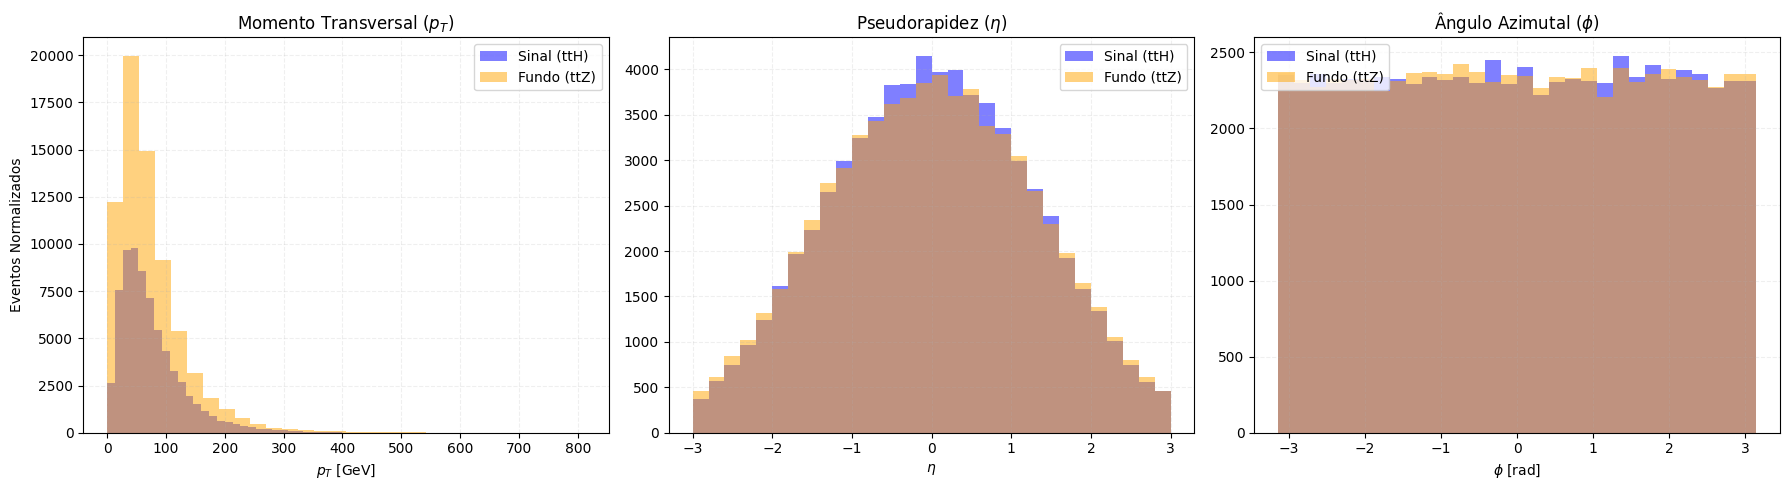

In [14]:
import pylhe
import matplotlib.pyplot as plt
import numpy as np

def calcular_cinematica(px, py, pz):
    # (pT)
    pt = np.sqrt(px**2 + py**2)
    p = np.sqrt(px**2 + py**2 + pz**2)

    # Pseudorapidez (Eta)
    if p - pz == 0 or p + pz == 0:
        eta = 0 # ou np.inf, mas 0 é seguro para plot
    else:
        eta = 0.5 * np.log((p + pz) / (p - pz))

    # (Phi)
    phi = np.arctan2(py, px)

    return pt, eta, phi

def extrair_dados_histograma(caminho_arquivo, ignora_neutrinos=True):
    """Lê o arquivo e retorna listas de pT, eta e phi para partículas finais (exceto neutrinos)"""
    pts, etas, phis = [], [], []

    for event in pylhe.read_lhe(caminho_arquivo):
      for p in event.particles:
        # Filtro 1: Status = 1 (Partícula Final Estável)
        if p.status == 1:
          # Filtro 2: Excluir Neutrinos (IDs 12, 14, 16 e seus negativos)
          if ignora_neutrinos:
            if abs(p.id) not in [12, 14, 16]:

              pt, eta, phi = calcular_cinematica(p.px, p.py, p.pz)
              pts.append(pt)
              etas.append(eta)
              phis.append(phi)
          else:
            pt, eta, phi = calcular_cinematica(p.px, p.py, p.pz)
            pts.append(pt)
            etas.append(eta)
            phis.append(phi)

    return pts, etas, phis

# --- 1. Extração dos Dados ---
s_pt, s_eta, s_phi = extrair_dados_histograma("data/sinal.lhe")
f_pt, f_eta, f_phi = extrair_dados_histograma("data/fundo.lhe")

# --- 2. Plotagem dos Histogramas ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
kwargs = dict(alpha=0.5, bins=30, ec="k")
# Nota: density=True normaliza a área para 1, facilitando comparar formas se o nº de eventos fosse diferente

# --- Plot 1: Momento Transversal (pT) ---
ax[0].hist(s_pt, range=(0, 400), color='blue', label='Sinal (ttH)', **kwargs)
ax[0].hist(f_pt, color='orange', label='Fundo (ttZ)', **kwargs)
ax[0].set_title("Momento Transversal ($p_T$)")
ax[0].set_xlabel("$p_T$ [GeV]")
ax[0].set_ylabel("Eventos Normalizados")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.2)

# --- Plot 2: Pseudorapidez (Eta) ---
ax[1].hist(s_eta, range=(-3, 3), color='blue', label='Sinal (ttH)', **kwargs)
ax[1].hist(f_eta, range=(-3, 3), color='orange', label='Fundo (ttZ)', **kwargs)
ax[1].set_title("Pseudorapidez ($\eta$)")
ax[1].set_xlabel("$\eta$")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.2)

# --- Plot 3: Ângulo Azimutal (Phi) ---
ax[2].hist(s_phi, range=(-np.pi, np.pi), color='blue', label='Sinal (ttH)', **kwargs)
ax[2].hist(f_phi, range=(-np.pi, np.pi), color='orange', label='Fundo (ttZ)', **kwargs)
ax[2].set_title("Ângulo Azimutal ($\phi$)")
ax[2].set_xlabel("$\phi$ [rad]")
ax[2].legend()
ax[2].grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

In [15]:
# --- Estatísticas dos Histogramas ---
print("="*50)
print("ESTATÍSTICAS DOS HISTOGRAMAS (ENTRADAS)")
print("="*50)

# O tamanho da lista de pT (len) é igual ao número total de partículas plotadas
print("pT")
print(f"SINAL: {len(s_pt)} eventos (ou seja {len(s_pt)} partículas)")
print(f"FUNDO: {len(f_pt)} eventos (ou seja {len(f_pt)} partículas)")
print("-"*50)
print("eta")
print(f"SINAL: {len(s_eta)} eventos (ou seja {len(s_eta)} partículas)")
print(f"FUNDO: {len(f_eta)} eventos (ou seja {len(f_eta)} partículas)")
print("-"*50)
print("phi")
print(f"SINAL: {len(s_phi)} eventos (ou seja {len(s_phi)} partículas)")
print(f"FUNDO: {len(f_phi)} eventos (ou seja {len(f_phi)} partículas)")

ESTATÍSTICAS DOS HISTOGRAMAS (ENTRADAS)
pT
SINAL: 70000 eventos (ou seja 70000 partículas)
FUNDO: 70000 eventos (ou seja 70000 partículas)
--------------------------------------------------
eta
SINAL: 70000 eventos (ou seja 70000 partículas)
FUNDO: 70000 eventos (ou seja 70000 partículas)
--------------------------------------------------
phi
SINAL: 70000 eventos (ou seja 70000 partículas)
FUNDO: 70000 eventos (ou seja 70000 partículas)


### Pergunta:
Os histogramas representam todos os eventos do arquivo LHE?  
Se não, explique o porquê (por exemplo: presença ou ausência de certas partículas nos eventos).

Não, os histogramas não representam todos os eventos do arquivo LHE. Primeiramente, só foram utilizados os eventos correspondentes aos estados finais, ou seja, os léptons que surgiram de decaimentos intermediários (status==1). Além disso, como solicitado nas instruções, foram ignorados os neutrinos (embora os neutrinos não sejam detectados de qualquer maneira) durante a construção dos histogramas.

# [4] Filtros e Cortes Cinemáticos

In [16]:
def extrair_dados_com_cortes(caminho_arquivo, pt_min, eta_max):
    pts, etas, phis = [], [], []
    total_particulas = 0
    aceitas = 0

    print(f"Processando {caminho_arquivo} com cortes (pT > {pt_min}, |eta| < {eta_max})...")

    for event in pylhe.read_lhe(caminho_arquivo):
        for p in event.particles:
            # Filtro base: Status 1 e não neutrino
            if p.status == 1 and abs(p.id) not in [12, 14, 16]:
                total_particulas += 1

                pt, eta, phi = calcular_cinematica(p.px, p.py, p.pz)

                # --- APLICAÇÃO DOS CORTES ---
                # Só guardamos se passar nas duas condições
                if (pt > pt_min) and (abs(eta) < eta_max):
                    pts.append(pt)
                    etas.append(eta)
                    phis.append(phi)
                    aceitas += 1

    return pts, etas, phis, total_particulas, aceitas

Processando data/sinal.lhe com cortes (pT > 40.0, |eta| < 2.1)...


<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-4101573840.py:22: SyntaxWarning: invalid escape sequence '\e'
  ax[1].axvline(ETA_MAX, color='k', linestyle='--', label=f'|$\eta$| < {ETA_MAX}') # Linha do corte
/tmp/ipython-input-4101573840.py:24: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_title(f"Pseudorapidez ($|\eta| < {ETA_MAX}$)")
/tmp/ipython-input-4101573840.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel("$\eta$")
/tmp/ipython-input-4101573840.py:31: SyntaxWarning: invalid

Processando data/fundo.lhe com cortes (pT > 40.0, |eta| < 2.1)...


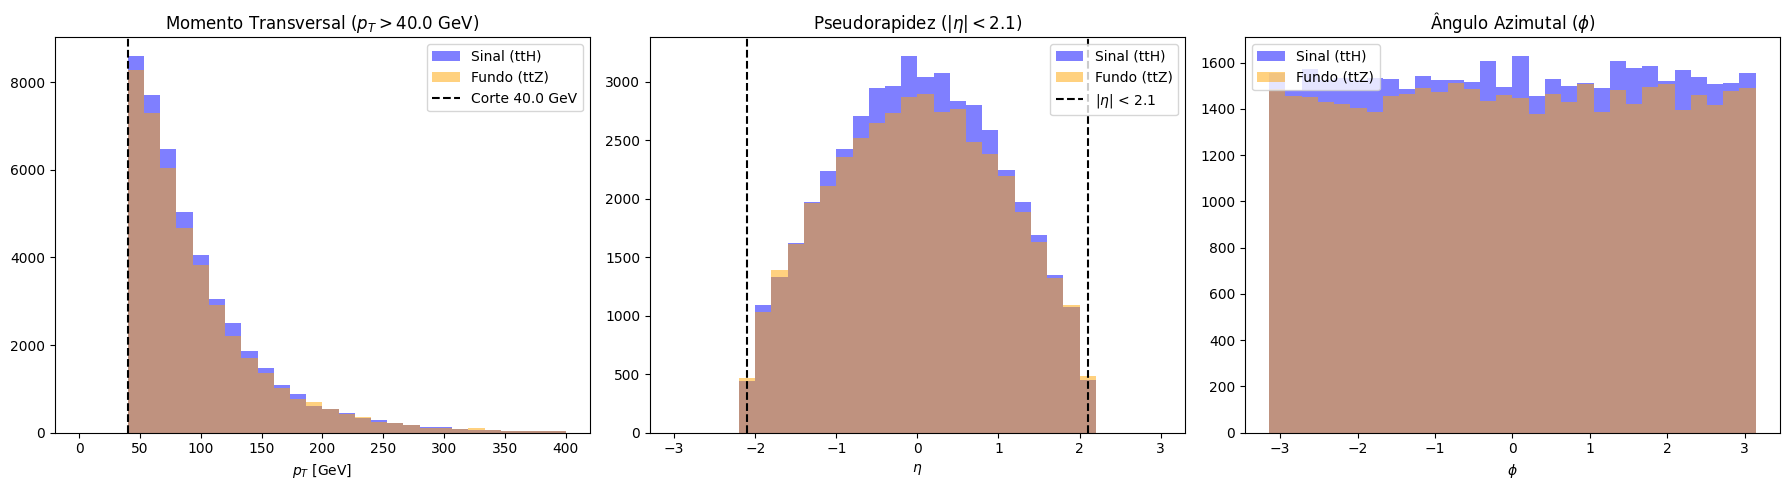


Corte realizado pT > 40.0
Corte realizado em eta < 2.1
ANÁLISE DE EFICIÊNCIA DOS CORTES
SINAL (ttH):
  - Partículas Totais: 70000
  - Partículas Aceitas: 46049
  - Perda: 34.22% das partículas foram cortadas.
------------------------------
FUNDO (ttZ):
  - Partículas Totais: 70000
  - Partículas Aceitas: 43564
  - Perda: 37.77% das partículas foram cortadas.


In [17]:
PT_MIN = 40.0
ETA_MAX = 2.1

s_pt, s_eta, s_phi, s_tot, s_ok = extrair_dados_com_cortes("data/sinal.lhe", PT_MIN, ETA_MAX)
f_pt, f_eta, f_phi, f_tot, f_ok = extrair_dados_com_cortes("data/fundo.lhe", PT_MIN, ETA_MAX)

# --- Plotagem ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
kwargs = dict(alpha=0.5, bins=30, ec="k")

# Plot pT
ax[0].hist(s_pt, range=(0, 400), color='blue', label='Sinal (ttH)', **kwargs)
ax[0].hist(f_pt, range=(0, 400), color='orange', label='Fundo (ttZ)', **kwargs)
ax[0].axvline(PT_MIN, color='k', linestyle='--', label=f'Corte {PT_MIN} GeV') # Linha do corte
ax[0].set_title(f"Momento Transversal ($p_T > {PT_MIN}$ GeV)")
ax[0].set_xlabel("$p_T$ [GeV]")
ax[0].legend()

# Plot Eta
ax[1].hist(s_eta, range=(-3, 3), color='blue', label='Sinal (ttH)', **kwargs)
ax[1].hist(f_eta, range=(-3, 3), color='orange', label='Fundo (ttZ)', **kwargs)
ax[1].axvline(ETA_MAX, color='k', linestyle='--', label=f'|$\eta$| < {ETA_MAX}') # Linha do corte
ax[1].axvline(-ETA_MAX, color='k', linestyle='--')
ax[1].set_title(f"Pseudorapidez ($|\eta| < {ETA_MAX}$)")
ax[1].set_xlabel("$\eta$")
ax[1].legend()

# Plot Phi
ax[2].hist(s_phi, range=(-np.pi, np.pi), color='blue', label='Sinal (ttH)', **kwargs)
ax[2].hist(f_phi, range=(-np.pi, np.pi), color='orange', label='Fundo (ttZ)', **kwargs)
ax[2].set_title("Ângulo Azimutal ($\phi$)")
ax[2].set_xlabel("$\phi$")
ax[2].legend()

plt.tight_layout()
plt.show()

# --- 3. Relatório de Eficiência dos Cortes ---
print("\n" + "="*60)
print(f"Corte realizado pT > {PT_MIN}")
print(f"Corte realizado em eta < {ETA_MAX}")
print("ANÁLISE DE EFICIÊNCIA DOS CORTES")
print("="*60)
print(f"SINAL (ttH):")
print(f"  - Partículas Totais: {s_tot}")
print(f"  - Partículas Aceitas: {s_ok}")
print(f"  - Perda: {100*(s_tot-s_ok)/s_tot:.2f}% das partículas foram cortadas.")
print("-" * 30)
print(f"FUNDO (ttZ):")
print(f"  - Partículas Totais: {f_tot}")
print(f"  - Partículas Aceitas: {f_ok}")
print(f"  - Perda: {100*(f_tot-f_ok)/f_tot:.2f}% das partículas foram cortadas.")
print("="*60)

# Podemos observar nos plots após os cortes com pT > 40.0 e |eta| < 2.1 que foi revelado um pouco do sinal (em azul) em relação ao fundo. Isso é mais notável no plot em phi, que é um fundo contínuo.

# Parte 2

##  [5] CONSERVAÇÃO DE ENERGIA

In [18]:
def calcular_mandelstam_s(caminho_arquivo, label):
    """
    Calcula a variável 's' (Massa Invariante ao quadrado) para eventos específicos.
    Filtra apenas partículas de Status 1 e remove Neutrinos.
    Indices alvo: 1 + 1000*i para i em [0, 9].
    """

    # Gera a lista de índices que queremos analisar: [1, 1001, 2001, ..., 9001]
    indices_alvo = [1 + 1000 * i for i in range(10)]

    print(f"\n{'='*60}")
    print(f"ANÁLISE DE CONSERVAÇÃO DE ENERGIA (Mandelstam s) - {label}")
    print(f"Critérios: Status=1, Sem Neutrinos")
    print(f"{'='*60}")

    # Contador manual já que o read_lhe é um gerador
    contador = 0

    for event in pylhe.read_lhe(caminho_arquivo):
        # Verifica se o evento atual está na nossa lista de alvos
        if contador in indices_alvo:

            # Inicializa os somatórios do quadrimomento
            E_tot = 0.0
            Px_tot = 0.0
            Py_tot = 0.0
            Pz_tot = 0.0

            n_particulas = 0

            for p in event.particles:
                # Filtro: Apenas partículas finais (1) e ignorar neutrinos (12, 14, 16)
                if p.status == 1 and abs(p.id) not in [12, 14, 16]:
                    E_tot  += p.e
                    Px_tot += p.px
                    Py_tot += p.py
                    Pz_tot += p.pz
                    n_particulas += 1

            # Cálculo de s = E^2 - P^2
            # P^2 = Px^2 + Py^2 + Pz^2
            P_mod_sq = Px_tot**2 + Py_tot**2 + Pz_tot**2
            s = E_tot**2 - P_mod_sq

            # Para facilitar a leitura física, calculamos também a sqrt(s) (Massa Invariante Visível)
            # Proteção contra raiz de número negativo (pode ocorrer por erro numérico muito pequeno)
            if s < 0:
                sqrt_s = 0.0
            else:
                sqrt_s = np.sqrt(s)

            print(f"Evento {contador:4d} | Partículas somadas: {n_particulas:2d} | "
                  f"s = {s:.2e} GeV²  (√s visível = {sqrt_s:.2f} GeV)")

        contador += 1

        # Otimização: Se já passamos do último índice que queremos, paramos de ler o arquivo
        if contador > max(indices_alvo):
            break

# --- EXECUÇÃO ---
# Calcular para o SINAL
calcular_mandelstam_s("data/sinal.lhe", "SINAL (ttH)")

# Calcular para o FUNDO
calcular_mandelstam_s("data/fundo.lhe", "FUNDO (ttZ)")


ANÁLISE DE CONSERVAÇÃO DE ENERGIA (Mandelstam s) - SINAL (ttH)
Critérios: Status=1, Sem Neutrinos
Evento    1 | Partículas somadas:  7 | s = 4.51e+05 GeV²  (√s visível = 671.91 GeV)


/tmp/ipython-input-1421759176.py:19: DeprecationWarning: read_lhe is deprecated and will be removed in a future version. Use `LHEFile.fromfile(...).events` instead
  for event in pylhe.read_lhe(caminho_arquivo):


Evento 1001 | Partículas somadas:  7 | s = 1.80e+05 GeV²  (√s visível = 424.02 GeV)
Evento 2001 | Partículas somadas:  7 | s = 2.97e+05 GeV²  (√s visível = 544.57 GeV)
Evento 3001 | Partículas somadas:  7 | s = 3.83e+05 GeV²  (√s visível = 619.18 GeV)
Evento 4001 | Partículas somadas:  7 | s = 1.30e+06 GeV²  (√s visível = 1138.88 GeV)
Evento 5001 | Partículas somadas:  7 | s = 1.57e+05 GeV²  (√s visível = 396.05 GeV)
Evento 6001 | Partículas somadas:  7 | s = 2.67e+05 GeV²  (√s visível = 516.63 GeV)
Evento 7001 | Partículas somadas:  7 | s = 2.87e+05 GeV²  (√s visível = 535.73 GeV)
Evento 8001 | Partículas somadas:  7 | s = 2.73e+05 GeV²  (√s visível = 522.07 GeV)
Evento 9001 | Partículas somadas:  7 | s = 4.44e+05 GeV²  (√s visível = 666.40 GeV)

ANÁLISE DE CONSERVAÇÃO DE ENERGIA (Mandelstam s) - FUNDO (ttZ)
Critérios: Status=1, Sem Neutrinos
Evento    1 | Partículas somadas:  7 | s = 1.37e+06 GeV²  (√s visível = 1168.82 GeV)
Evento 1001 | Partículas somadas:  7 | s = 3.47e+05 GeV²  (

## [6] RECONSTRUÇÃO DE VARIÁVEIS

<>:115: SyntaxWarning: invalid escape sequence '\e'
<>:117: SyntaxWarning: invalid escape sequence '\e'
<>:122: SyntaxWarning: invalid escape sequence '\e'
<>:124: SyntaxWarning: invalid escape sequence '\e'
<>:115: SyntaxWarning: invalid escape sequence '\e'
<>:117: SyntaxWarning: invalid escape sequence '\e'
<>:122: SyntaxWarning: invalid escape sequence '\e'
<>:124: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-126093718.py:115: SyntaxWarning: invalid escape sequence '\e'
  ax[1,0].set_title("3. SINAL: $M_{bb}$ vs $\eta_{pair}$")
/tmp/ipython-input-126093718.py:117: SyntaxWarning: invalid escape sequence '\e'
  ax[1,0].set_ylabel("Pseudorapidez ($\eta$)")
/tmp/ipython-input-126093718.py:122: SyntaxWarning: invalid escape sequence '\e'
  ax[1,1].set_title("4. FUNDO: $M_{bb}$ vs $\eta_{pair}$")
/tmp/ipython-input-126093718.py:124: SyntaxWarning: invalid escape sequence '\e'
  ax[1,1].set_ylabel("Pseudorapidez ($\eta$)")
/tmp/ipython-input-126093718.py:50: DeprecationW

Processando reconstrução para: data/sinal.lhe ...
Processando reconstrução para: data/fundo.lhe ...


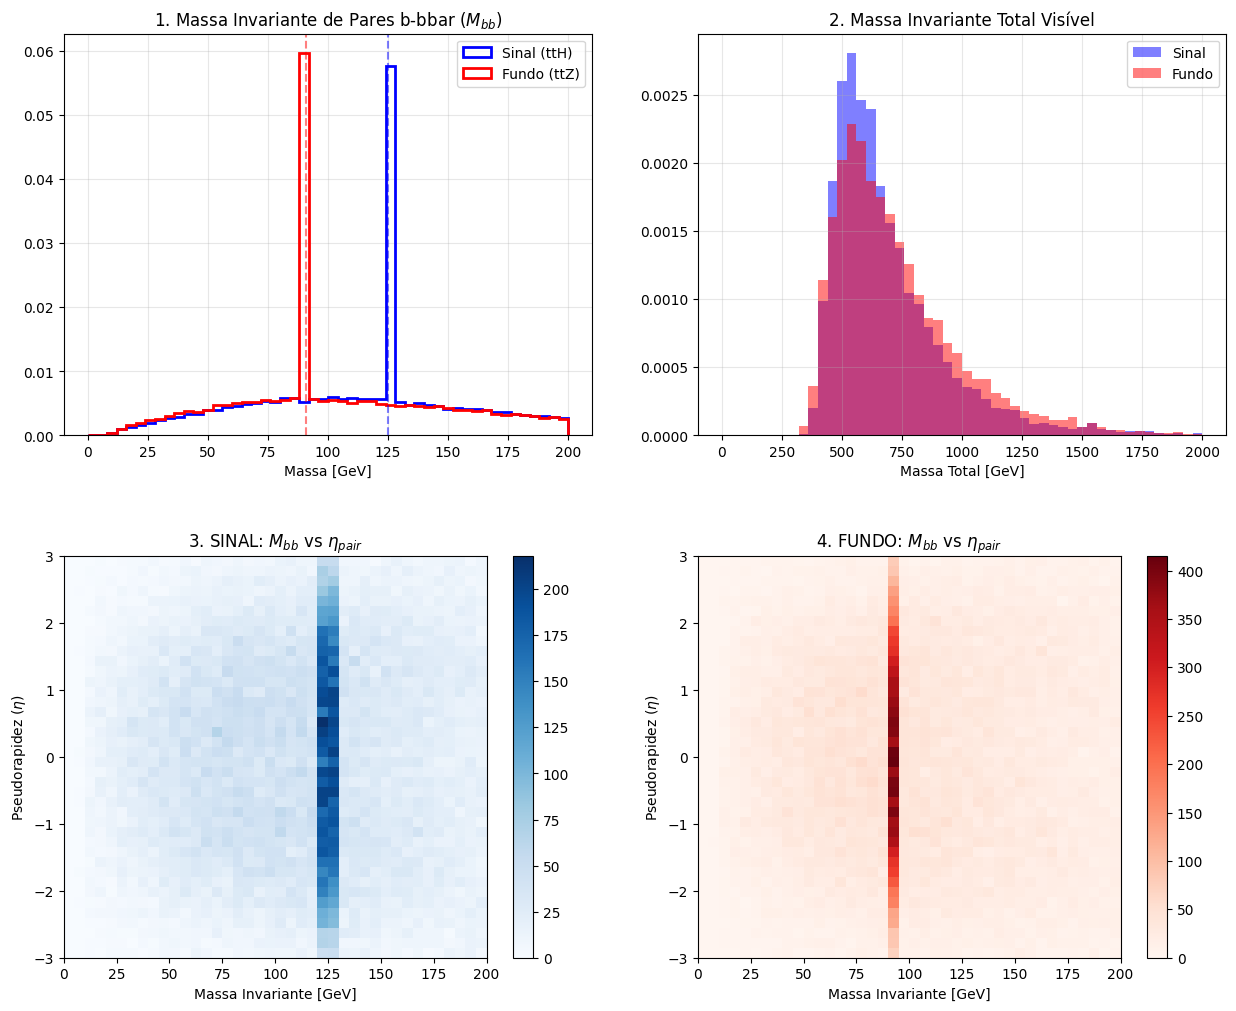

In [19]:
def get_invariant_mass_pair(p1, p2):
    """Calcula a massa invariante de um par de partículas."""
    e_tot = p1.e + p2.e
    px_tot = p1.px + p2.px
    py_tot = p1.py + p2.py
    pz_tot = p1.pz + p2.pz

    # M^2 = E^2 - P^2
    p_sq = px_tot**2 + py_tot**2 + pz_tot**2
    mass_sq = e_tot**2 - p_sq

    # Proteção numérica e cálculo de Eta do sistema
    mass = np.sqrt(max(0, mass_sq))

    # Cálculo da Rapidez (Eta) do sistema composto
    p_mod = np.sqrt(p_sq)
    if p_mod - pz_tot == 0 or p_mod + pz_tot == 0:
        eta = 0
    else:
        eta = 0.5 * np.log((p_mod + pz_tot) / (p_mod - pz_tot))

    return mass, eta

def get_total_visible_mass(particles):
    """Calcula a massa invariante de todas as partículas visíveis somadas."""
    e_tot, px_tot, py_tot, pz_tot = 0, 0, 0, 0

    for p in particles:
        e_tot += p.e
        px_tot += p.px
        py_tot += p.py
        pz_tot += p.pz

    mass_sq = e_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2)
    return np.sqrt(max(0, mass_sq))

def processar_reconstrucao(arquivo_lhe):
    """
    Lê o arquivo e extrai:
    1. Massas de todos os pares b-bbar possíveis.
    2. Etas desses pares.
    3. Massa total do evento.
    """
    massas_pares_bb = []
    etas_pares_bb = []
    massas_totais = []

    print(f"Processando reconstrução para: {arquivo_lhe} ...")

    for event in pylhe.read_lhe(arquivo_lhe):
        # 1. Selecionar partículas de interesse (Status 1)
        # Vamos focar nos b-quarks (ID 5 e -5) para reconstruir H ou Z
        b_quarks = []
        visiveis = []

        for p in event.particles:
            if p.status == 1:
                # Se não for neutrino, adiciona à lista de visíveis totais
                if abs(p.id) not in [12, 14, 16]:
                    visiveis.append(p)

                # Se for b-quark (jato), guarda para pareamento
                if abs(p.id) == 5:
                    b_quarks.append(p)

        # --- TAREFA 1: Pares de Partículas (b-bbar) ---
        # Como temos 4 b-quarks por evento, não sabemos qual par veio do Higgs.
        # Vamos calcular TODAS as combinações possíveis (Combinatorial Background).
        if len(b_quarks) >= 2:
            # itertools.combinations pega todos os pares possíveis sem repetição
            for p1, p2 in itertools.combinations(b_quarks, 2):
                m, eta = get_invariant_mass_pair(p1, p2)
                massas_pares_bb.append(m)
                etas_pares_bb.append(eta)

        # --- TAREFA 2: Massa Total do Evento ---
        if visiveis:
            m_tot = get_total_visible_mass(visiveis)
            massas_totais.append(m_tot)

    return massas_pares_bb, etas_pares_bb, massas_totais

# --- EXECUÇÃO DA ANÁLISE ---
# Extrair dados do Sinal
s_m_bb, s_eta_bb, s_m_total = processar_reconstrucao("data/sinal.lhe")

# Extrair dados do Fundo
f_m_bb, f_eta_bb, f_m_total = processar_reconstrucao("data/fundo.lhe")

# --- PLOTAGEM ---
fig, ax = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# 1. Histograma de Pares b-bbar (A busca pelo pico!)
ax[0,0].hist(s_m_bb, range=(0, 200), bins=50, histtype='step', color='blue', label='Sinal (ttH)', density=True, linewidth=2)
ax[0,0].hist(f_m_bb, range=(0, 200), bins=50, histtype='step', color='red', label='Fundo (ttZ)', density=True, linewidth=2)
ax[0,0].set_title("1. Massa Invariante de Pares b-bbar ($M_{bb}$)")
ax[0,0].set_xlabel("Massa [GeV]")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)
# Linhas teóricas
ax[0,0].axvline(125, color='blue', linestyle='--', alpha=0.5, label='Higgs Mass')
ax[0,0].axvline(91, color='red', linestyle='--', alpha=0.5, label='Z Mass')

# 2. Histograma de Massa Total Visível
ax[0,1].hist(s_m_total, range=(0, 2000), bins=50, color='blue', alpha=0.5, label='Sinal', density=True)
ax[0,1].hist(f_m_total, range=(0, 2000), bins=50, color='red', alpha=0.5, label='Fundo', density=True)
ax[0,1].set_title("2. Massa Invariante Total Visível")
ax[0,1].set_xlabel("Massa Total [GeV]")
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

# 3. Mapa de Calor 2D - SINAL (Massa vs Eta)
h1 = ax[1,0].hist2d(s_m_bb, s_eta_bb, bins=40, range=[[0, 200], [-3, 3]], cmap='Blues')
ax[1,0].set_title("3. SINAL: $M_{bb}$ vs $\eta_{pair}$")
ax[1,0].set_xlabel("Massa Invariante [GeV]")
ax[1,0].set_ylabel("Pseudorapidez ($\eta$)")
fig.colorbar(h1[3], ax=ax[1,0])

# 4. Mapa de Calor 2D - FUNDO (Massa vs Eta)
h2 = ax[1,1].hist2d(f_m_bb, f_eta_bb, bins=40, range=[[0, 200], [-3, 3]], cmap='Reds')
ax[1,1].set_title("4. FUNDO: $M_{bb}$ vs $\eta_{pair}$")
ax[1,1].set_xlabel("Massa Invariante [GeV]")
ax[1,1].set_ylabel("Pseudorapidez ($\eta$)")
fig.colorbar(h2[3], ax=ax[1,1])

plt.show()

# [7] GRÁFICOS E VISUALIZAÇÃO

Lendo data/sinal.lhe.gz...
Lendo data/fundo.lhe.gz...

RESUMO DA NORMALIZAÇÃO:
SINAL (ttH): Xsec=3.7568e-02 pb | N_sim=10000 | Peso=0.0376
FUNDO (ttZ): Xsec=1.2436e-02 pb | N_sim=10000 | Peso=0.0124


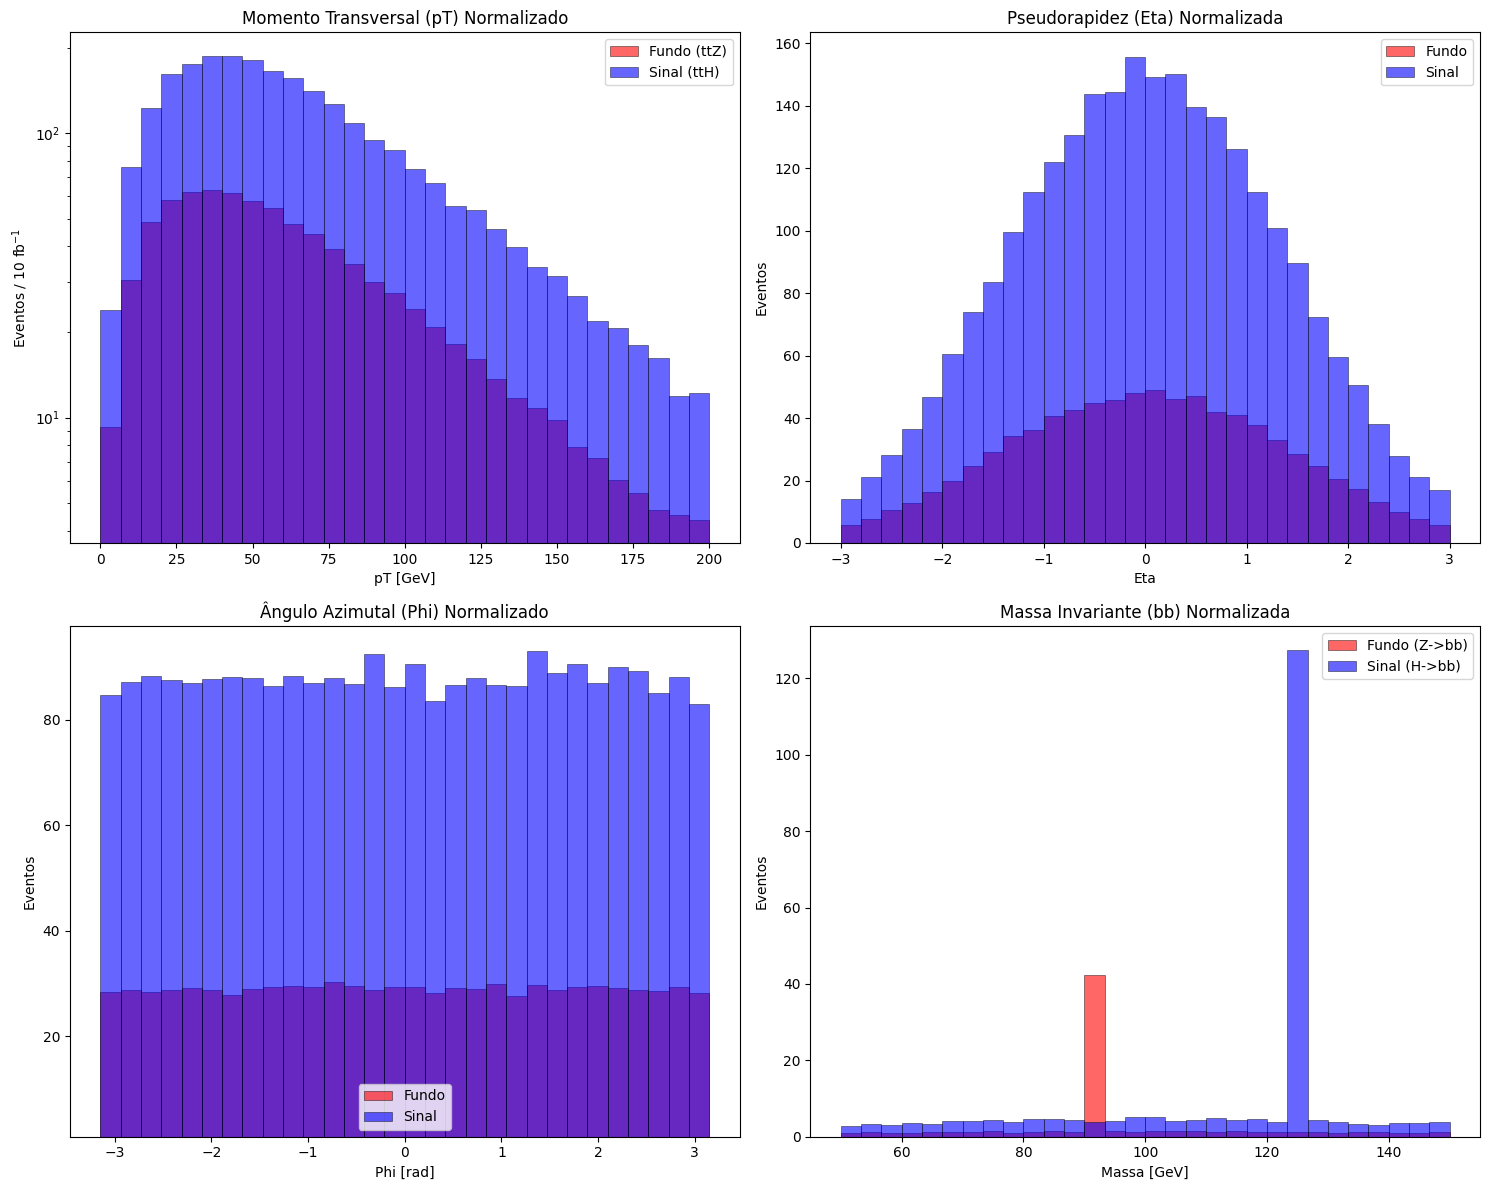

In [20]:
LUMINOSIDADE = 10000.0  # pb^-1 (equivalente a 10 /fb)
FILE_SINAL = "data/sinal.lhe.gz" # Ajuste o caminho se necessário
FILE_FUNDO = "data/fundo.lhe.gz"

# --- 1. LEITOR MANUAL DE LHE (Para garantir extração do XSEC) ---
class Particle:
    def __init__(self, parts):
        self.id = int(parts[0])
        self.status = int(parts[1])
        self.mother1 = int(parts[2])
        self.px = float(parts[6])
        self.py = float(parts[7])
        self.pz = float(parts[8])
        self.e = float(parts[9])

def processar_lhe_completo(filename):
    """
    Lê o arquivo LHE e retorna:
    1. A Seção de Choque (XSEC) em pb lida do bloco <init>
    2. A lista de eventos (para contagem total)
    3. As listas de dados extraídos (pT, Eta, Phi, Massa_bb)
    """
    events_kinematics = {'pt': [], 'eta': [], 'phi': []}
    massas_bb = []
    xsec = 0.0
    n_total_events = 0

    print(f"Lendo {filename}...")

    # Abre arquivo (suporta .gz ou texto normal)
    open_func = gzip.open if filename.endswith('.gz') else open

    with open_func(filename, 'rt') as f:
        in_init = False
        in_event = False
        beam_line_read = False
        current_particles = []

        for line in f:
            line = line.strip()
            if not line: continue

            # -- Leitura do XSEC no bloco INIT --
            if "<init>" in line:
                in_init = True
                continue
            if "</init>" in line:
                in_init = False
                continue

            if in_init:
                if not beam_line_read:
                    beam_line_read = True # Pula linha dos feixes
                    continue
                try:
                    # O primeiro número da linha de processo é o XSEC (pb)
                    xsec = float(line.split()[0])
                    in_init = False # Já temos o que precisamos
                except: pass
                continue

            # -- Leitura de EVENTOS --
            if "<event>" in line:
                in_event = True
                current_particles = []
                n_total_events += 1
                continue
            if "</event>" in line:
                in_event = False
                # Processar o evento que acabou de fechar
                processar_evento(current_particles, events_kinematics, massas_bb)
                continue

            if in_event:
                parts = line.split()
                if len(parts) > 10: # Linha de partícula válida
                    current_particles.append(Particle(parts))

    return xsec, n_total_events, events_kinematics, massas_bb

def processar_evento(particles, kinematics, massas):
    # 1. Cinemática (pT, Eta, Phi) para partículas finais (Status 1, sem neutrinos)
    b_quarks = [] # Para reconstrução de massa

    for p in particles:
        if p.status == 1:
            if abs(p.id) not in [12, 14, 16]: # Ignora neutrinos
                pt = np.sqrt(p.px**2 + p.py**2)
                p_mod = np.sqrt(p.px**2 + p.py**2 + p.pz**2)
                eta = 0 if (p_mod == abs(p.pz)) else 0.5 * math.log((p_mod + p.pz) / (p_mod - p.pz))
                phi = math.atan2(p.py, p.px)

                kinematics['pt'].append(pt)
                kinematics['eta'].append(eta)
                kinematics['phi'].append(phi)

            # Seleciona b-quarks para massa
            if abs(p.id) == 5:
                b_quarks.append(p)

    # 2. Reconstrução de Massa (Pares b-bbar)
    # Simples: Se houver >= 2 b-quarks, calcula massa do par principal (ou todos)
    # Aqui calculamos do par de maior pT ou todos os pares (combinatória)
    # Para simplificar e focar no pico, vamos pegar os 2 primeiros b encontrados (ou usar info da mãe se disponível)
    if len(b_quarks) >= 2:
        p1, p2 = b_quarks[0], b_quarks[1] # Pega o primeiro par
        e = p1.e + p2.e
        px = p1.px + p2.px
        py = p1.py + p2.py
        pz = p1.pz + p2.pz
        m2 = e**2 - (px**2 + py**2 + pz**2)
        if m2 > 0:
            massas.append(np.sqrt(m2))

# --- 2. EXECUÇÃO E CÁLCULO DE PESOS ---

# Processa Sinal
xsec_s, N_s, data_s, mass_s = processar_lhe_completo(FILE_SINAL)
weight_s = (xsec_s * LUMINOSIDADE) / N_s

# Processa Fundo
xsec_f, N_f, data_f, mass_f = processar_lhe_completo(FILE_FUNDO)
weight_f = (xsec_f * LUMINOSIDADE) / N_f

print(f"\nRESUMO DA NORMALIZAÇÃO:")
print(f"SINAL (ttH): Xsec={xsec_s:.4e} pb | N_sim={N_s} | Peso={weight_s:.4f}")
print(f"FUNDO (ttZ): Xsec={xsec_f:.4e} pb | N_sim={N_f} | Peso={weight_f:.4f}")

# --- 3. PLOTAGEM ---
fig, ax = plt.subplots(2, 2, figsize=(15, 12))
style = dict(alpha=0.6, bins=30, edgecolor='black', linewidth=0.5)

# Função auxiliar para criar vetor de pesos do tamanho dos dados
def get_weights(data_list, weight_val):
    return [weight_val] * len(data_list)

# Plot 1: pT
ax[0,0].hist(data_f['pt'], weights=get_weights(data_f['pt'], weight_f),
             range=(0, 200), color='red', label='Fundo (ttZ)', **style)
ax[0,0].hist(data_s['pt'], weights=get_weights(data_s['pt'], weight_s),
             range=(0, 200), color='blue', label='Sinal (ttH)', **style)
ax[0,0].set_yscale('log') # Log scale é essencial pois o Fundo é muito maior
ax[0,0].set_title("Momento Transversal (pT) Normalizado")
ax[0,0].set_xlabel("pT [GeV]")
ax[0,0].set_ylabel(f"Eventos / {LUMINOSIDADE/1000:.0f} fb$^{{-1}}$")
ax[0,0].legend()

# Plot 2: Eta
ax[0,1].hist(data_f['eta'], weights=get_weights(data_f['eta'], weight_f),
             range=(-3, 3), color='red', label='Fundo', **style)
ax[0,1].hist(data_s['eta'], weights=get_weights(data_s['eta'], weight_s),
             range=(-3, 3), color='blue', label='Sinal', **style)
ax[0,1].set_title("Pseudorapidez (Eta) Normalizada")
ax[0,1].set_xlabel("Eta")
ax[0,1].set_ylabel("Eventos")
ax[0,1].legend()

# Plot 3: Phi
ax[1,0].hist(data_f['phi'], weights=get_weights(data_f['phi'], weight_f),
             range=(-3.15, 3.15), color='red', label='Fundo', **style)
ax[1,0].hist(data_s['phi'], weights=get_weights(data_s['phi'], weight_s),
             range=(-3.15, 3.15), color='blue', label='Sinal', **style)
ax[1,0].set_title("Ângulo Azimutal (Phi) Normalizado")
ax[1,0].set_xlabel("Phi [rad]")
ax[1,0].set_ylabel("Eventos")
ax[1,0].set_ylim(bottom=1) # Ajuste para log se necessário
ax[1,0].legend(loc='lower center')

# Plot 4: Massa Invariante (bb)
ax[1,1].hist(mass_f, weights=get_weights(mass_f, weight_f),
             range=(50, 150), color='red', label='Fundo (Z->bb)', **style)
ax[1,1].hist(mass_s, weights=get_weights(mass_s, weight_s),
             range=(50, 150), color='blue', label='Sinal (H->bb)', **style)
ax[1,1].set_title("Massa Invariante (bb) Normalizada")
ax[1,1].set_xlabel("Massa [GeV]")
ax[1,1].set_ylabel("Eventos")
ax[1,1].legend()

plt.tight_layout()
plt.show()

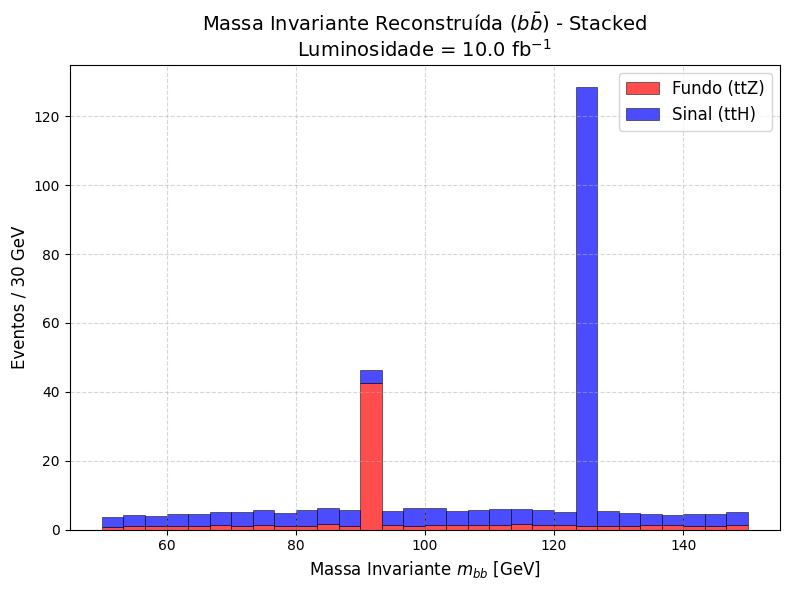

In [25]:
# --- Assumindo que mass_s, mass_f, weight_s, weight_f já foram calculados no passo 2 ---

# Configuração da figura
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Organizar os dados em listas na ordem de empilhamento
# Ordem: [Fundo (base), Sinal (topo)]
dados_stack = [mass_f, mass_s]

# 2. Organizar os pesos correspondentes na mesma estrutura
pesos_stack = [
    [weight_f] * len(mass_f),  # Vetor de pesos para cada evento de fundo
    [weight_s] * len(mass_s)   # Vetor de pesos para cada evento de sinal
]

# 3. Definições estéticas
cores = ['red', 'blue']
labels = ['Fundo (ttZ)', 'Sinal (ttH)']
bins = 30
intervalo = (50, 150) # GeV

# 4. Plotagem Stacked
counts, bin_edges, patches = ax.hist(
    dados_stack,
    weights=pesos_stack,
    bins=bins,
    range=intervalo,
    stacked=True,            # <--- O argumento principal para empilhar
    color=cores,
    label=labels,
    edgecolor='black',       # Borda preta ajuda a separar as cores
    linewidth=0.5,
    alpha=0.7                # Transparência leve
)

# Decoração do gráfico
ax.set_title(f"Massa Invariante Reconstruída ($b\\bar{{b}}$) - Stacked\nLuminosidade = {LUMINOSIDADE/1000:.1f} fb$^{{-1}}$", fontsize=14)
ax.set_xlabel("Massa Invariante $m_{bb}$ [GeV]", fontsize=12)
ax.set_ylabel(f"Eventos / {bins} GeV", fontsize=12)

# Adiciona Grid e Legenda
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')

# Opcional: Eixos Logarítmicos (muito comum se o fundo for muito maior que o sinal)
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

## [8] COMENTÁRIOS

Faz sentido a proporção entre os histogramas normalizados com base na seção de choque presente nos arquivos LHE?
Você verifica alguma estrutura particular nas disitrubuições de massa invariante?

Resposta:

A proporção dos histogramas faz sentido. Antes de aplicar a normalização a seção de choque e, portanto, a luminosidade do fundo e do sinal eram diferentes. Ao aplicar a normalização com base na seção de choque observamos uma proporção entre o fundo e o sinal. Ambos histogramas apresentam um fundo contínuo, com picos nas suas respectivas massas. O pico e os valores contínuos do sinal são maiores que do fundo, a razão disso é que os cortes aplicados anteriormente retiraram alguns dos eventos de fundo, fazendo aparecer mais eventos correspondente ao sinal.

Existe uma estrutura relevante na distribuição da massa invariante, porque os plots apresentam dois picos em valores distindos. Em aproximadamente 91 GeV existe um pico devido a contribuição do fundo. Esse pico é a contribuição da massa do Bóson Z, justamente a partícula correspondente ao processo identificado anteriormente. Analogamente, existe um pico em 125 GeV, dessa vez pela contribuição do sinal. Pelo mesmo motivo, esse pico é devido a massa do bóson de Higgs, como esperado, já que foi identificado que o arquivo de sinal corresponde a um processo envolvendo Higgs.